In [1]:
import pandas as pd
import numpy as np

# Load Dataset

In [2]:
xtrain = pd.read_csv("X_train.csv")
xtrain = xtrain.iloc[:,2:] # Remove CustomerId and Surname
xtrain.shape

(6499, 10)

In [3]:
xtrain.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,791,Germany,Female,35,7,52436.20,1,1,0,161051.75
1,705,Germany,Male,42,8,166685.92,2,1,1,55313.51
2,543,France,Female,31,4,138317.94,1,0,0,61843.73
3,709,France,Female,32,2,0.00,2,0,0,109681.29
4,714,Germany,Female,36,1,101609.01,2,1,1,447.73


# Data Pre-processing

In [4]:
def preprocess_data(df):
    """
    Preprocesses the input DataFrame for the churn dataset.
    Removes ID columns, encodes categorical features, and selects key features.
    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset (train or test)
    Returns
    -------
    df : pandas.DataFrame
        Preprocessed dataset with selected features only.
    """
    # 1️⃣ Drop first two columns (CustomerId, Surname)
    df = df.iloc[:, 2:].copy()

    # 2️⃣ Clean and encode Gender
    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()
        df["Gender"] = df["Gender"].map({"female": 0, "male": 1})
        df["Gender"] = df["Gender"].fillna(df["Gender"].median())

    # 3️⃣ Encode Geography as categorical codes
    if "Geography" in df.columns:
        df["Geography"] = df["Geography"].astype("category").cat.codes

    # 4️⃣ Select important features
    selected_features = ["Age", "Balance", "Geography", "EstimatedSalary"]
    df = df[selected_features]

    return df

In [5]:
# Strip whitespace and lowercase first
xtrain["Gender"] = xtrain["Gender"].str.strip().str.lower()
xtrain["Gender"] = xtrain["Gender"].map({"female": 0, "male": 1})
xtrain["Geography"] = xtrain["Geography"].astype("category").cat.codes
xtrain["Gender"] = xtrain["Gender"].fillna(xtrain["Gender"].median())
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      6499 non-null   int64  
 1   Geography        6499 non-null   int8   
 2   Gender           6499 non-null   int64  
 3   Age              6499 non-null   int64  
 4   Tenure           6499 non-null   int64  
 5   Balance          6499 non-null   float64
 6   NumOfProducts    6499 non-null   int64  
 7   HasCrCard        6499 non-null   int64  
 8   IsActiveMember   6499 non-null   int64  
 9   EstimatedSalary  6499 non-null   float64
dtypes: float64(2), int64(7), int8(1)
memory usage: 463.4 KB


In [6]:
xtrain.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,791,1,0,35,7,52436.20,1,1,0,161051.75
1,705,1,1,42,8,166685.92,2,1,1,55313.51
2,543,0,0,31,4,138317.94,1,0,0,61843.73
3,709,0,0,32,2,0.00,2,0,0,109681.29
4,714,1,0,36,1,101609.01,2,1,1,447.73


In [7]:
ytrain = pd.read_csv("y_train.csv")
ytrain = ytrain.iloc[:,-1]
ytrain.shape

(6499,)

In [8]:
data = xtrain.join(ytrain)
corr_matrix = data.corr()
feature_target_corr = corr_matrix['Exited'].sort_values(ascending=False)
print(feature_target_corr)

Exited             1.000000
Age                0.290102
Balance            0.110606
Geography          0.037374
EstimatedSalary    0.008826
Tenure            -0.003436
HasCrCard         -0.008876
CreditScore       -0.031130
NumOfProducts     -0.061488
Gender            -0.103850
IsActiveMember    -0.154442
Name: Exited, dtype: float64


# feature selection

In [9]:
selected_features  = ["Age", "Balance", "Geography", "EstimatedSalary"]
xtrain = xtrain[selected_features]
display(xtrain.head())
print(xtrain.shape)

,Age,Balance,Geography,EstimatedSalary
0,35,52436.20,1,161051.75
1,42,166685.92,1,55313.51
2,31,138317.94,0,61843.73
3,32,0.00,0,109681.29
4,36,101609.01,1,447.73


(6499, 4)


# model Building 🏋️‍♂️

In [10]:
def PLr (xtrain, ytrain, lr = 0.1, epochs = 5000) :
  xtrain = np.insert(xtrain, 0, 1, axis=1)
  w = np.ones(xtrain.shape[1])
  for _ in range(epochs) :
    j = np.random.randint(xtrain.shape[0])
    y_pred = sigmoid(np.dot(xtrain[j], w)) # < - - here sigmoid functn
    w = w + lr * (ytrain[j] - y_pred) * xtrain[j]
  return w[0], w[1:]  # < - w[0] (intercept) and reset are coefficient

def sigmoid (z) :
  return 1/(1+np.exp(-z))

def predict(x, w0, w):
    # Add intercept column (bias term)
    x = np.insert(x, 0, 1, axis=1)
    z = np.dot(x, np.concatenate(([w0], w)))
    y_prob = sigmoid(z)
    # Convert to binary predictions (0 or 1)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_pred, y_prob

def get_line_params(w0, w):
    slope = -w[0] / w[1]
    intercept = -w0 / w[1]
    return slope, intercept

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(xtrain.values)

w0, w = PLr(X_train_scaled, ytrain.values, lr=0.01, epochs=10000)
y_pred, y_prob = predict(xtrain.values, w0, w)

In [12]:
xtest = preprocess_data(pd.read_csv("X_test.csv"))
xtest.head()

,Age,Balance,Geography,EstimatedSalary
0,60,92887.06,0,39473.63
1,56,115895.22,0,4176.17
2,32,75170.54,0,37898.50
3,34,107556.06,2,154631.35
4,62,0.00,0,100941.57


In [13]:
X_test = xtest.values  # convert DataFrame → NumPy array
X_test = scaler.transform(X_test)  # scale the data
y_pred, y_prob = predict(X_test, w0, w)

In [14]:
ytest = pd.read_csv("y_test.csv")
ytest = ytest.iloc[:,-1]
ytest.shape

(3501,)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
y_pred_custom = (y_prob >= 0.3).astype(int)
# ytrain or ytest depending on what you used
y_true = ytest.values  # or ytest if available

print("📈 Model Performance on Training Data")
print("------------------------------------")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

# Optional detailed report
print("\nClassification Report:\n", classification_report(y_true, y_pred))


📈 Model Performance on Training Data
------------------------------------
Accuracy : 0.7792059411596687
Precision: 0.27611940298507465
Recall   : 0.051893408134642355
F1 Score : 0.08736717827626919

Confusion Matrix:
 [[2691   97]
 [ 676   37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.87      2788
           1       0.28      0.05      0.09       713

    accuracy                           0.78      3501
   macro avg       0.54      0.51      0.48      3501
weighted avg       0.69      0.78      0.71      3501



In [16]:
print("Unique predictions:", np.unique(y_pred, return_counts=True))
print("Mean probability:", y_prob.mean())

Unique predictions: (array([0, 1]), array([3367,  134]))
Mean probability: 0.19264082900575263


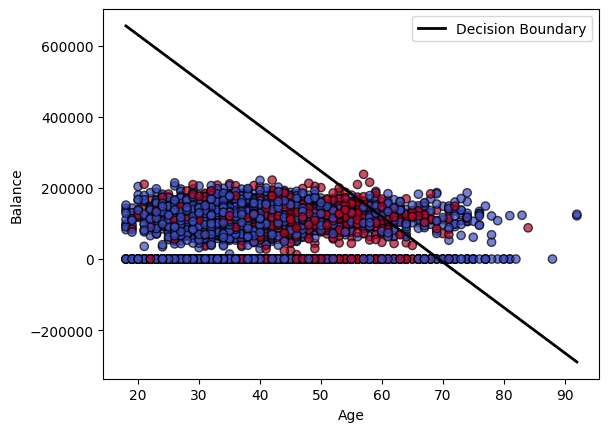

In [17]:
import matplotlib.pyplot as plt
# Using StandardScaler object `scaler`

x1_scaled = X_train_scaled[:, 0]  # Age scaled
x2_scaled = X_train_scaled[:, 1]  # Balance scaled

age_mean, age_std = scaler.mean_[0], np.sqrt(scaler.var_[0])
balance_mean, balance_std = scaler.mean_[1], np.sqrt(scaler.var_[1])

# Get line in scaled coordinates
slope, intercept = get_line_params(w0, w[:2])
x_scaled = np.linspace(x1_scaled.min(), x1_scaled.max(), 100)
y_scaled = slope * x_scaled + intercept

# Convert back to original
x_orig = x_scaled * age_std + age_mean
y_orig = y_scaled * balance_std + balance_mean

plt.scatter(xtrain["Age"], xtrain["Balance"], c=ytrain, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.plot(x_orig, y_orig, color='black', linewidth=2, label='Decision Boundary')
plt.xlabel("Age")
plt.ylabel("Balance")
plt.legend()
plt.show()
